# Decomposition

## Global Importation

In [3]:
# Shape modules 
from collections import defaultdict

# Computational modules 
%matplotlib inline
import xarray as xr
import glob
import os
import numpy as np
import netCDF4
from netCDF4 import Dataset
import pandas as pd
import re
from array import array
from pylab import *
from scipy.stats import ttest_ind

#import geopandas
#from eofs.xarray import Eof
#from eofs.multivariate.standard import MultivariateEof
import random
import cftime

# Plotting modules 
import matplotlib.pyplot as plt

#from mpl_toolkits.basemap import Basemap
import pandas.plotting
import matplotlib.ticker as ticker

#import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm
from cartopy.util import add_cyclic_point
from shapely.geometry import Polygon as ShapelyPolygon

"""
# Scikit-learn
from sklearn import linear_model
from sklearn.linear_model import LassoCV, LassoLarsCV, LassoLarsIC
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score
from sklearn import preprocessing
from sklearn import tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix
from sklearn import metrics
from sklearn.neural_network import MLPRegressor
from scipy.optimize import minimize
from scipy.optimize import dual_annealing
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist
import scipy.stats as stats
from scipy.stats import ttest_ind
"""

# Dask
import dask
"""
from dask import delayed, compute
from dask.distributed import Client
"""

# tqdm + Remove warnings
from tqdm import tqdm 
import warnings
warnings.filterwarnings('ignore')

## Global Inset

### Load Decomposition Results

In [4]:
path_decomp_files = '/home/users/alvin_ch/files/Multi-model/UKESM_ramp_up/Decomposition'
path_decomp_figure = '/home/users/alvin_ch/figures/Multi-model/UKESM_ramp_up/Decomposition'

save_names = ['complete_timeline_ramp_up_decompose']

decomposed_raw_results = {}

for file in tqdm(save_names):
    results_open = xr.open_dataset(f"{path_decomp_files}/{file}.nc")
    decomposed_raw_results = results_open

100%|███████████████████████████████████████████| 1/1 [00:01<00:00,  1.62s/it]


### Load Student-t Results

In [5]:
var_list = ['delta_precip', 'thermodynamic', 'dynamic', 'cross_term']

names = ['1.5-degree branch-off', '2-degree branch-off', '3-degree branch-off',
         '4-degree branch-off', '5-degree branch-off', '6-degree branch-off']

path_pval_1p5deg_files = []
path_pval_2deg_files = []
path_pval_3deg_files = []
path_pval_4deg_files = []
path_pval_5deg_files = []
path_pval_6deg_files = []

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[0]}/ramp_up_{names[0]}_window_{variable}_pvalues.nc'
    path_pval_1p5deg_files.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[1]}/ramp_up_{names[1]}_window_{variable}_pvalues.nc'
    path_pval_2deg_files.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[2]}/ramp_up_{names[2]}_window_{variable}_pvalues.nc'
    path_pval_3deg_files.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[3]}/ramp_up_{names[3]}_window_{variable}_pvalues.nc'
    path_pval_4deg_files.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[4]}/ramp_up_{names[4]}_window_{variable}_pvalues.nc'
    path_pval_5deg_files.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[5]}/ramp_up_{names[5]}_window_{variable}_pvalues.nc'
    path_pval_6deg_files.append(temp_path)

In [6]:
path_pval_1p5deg_files_MJJAS = []
path_pval_2deg_files_MJJAS = []
path_pval_3deg_files_MJJAS = []
path_pval_4deg_files_MJJAS = []
path_pval_5deg_files_MJJAS = []
path_pval_6deg_files_MJJAS = []

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[0]}/ramp_up_{names[0]}_window_MJJAS_{variable}_pvalues.nc'
    path_pval_1p5deg_files_MJJAS.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[1]}/ramp_up_{names[1]}_window_MJJAS_{variable}_pvalues.nc'
    path_pval_2deg_files_MJJAS.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[2]}/ramp_up_{names[2]}_window_MJJAS_{variable}_pvalues.nc'
    path_pval_3deg_files_MJJAS.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[3]}/ramp_up_{names[3]}_window_MJJAS_{variable}_pvalues.nc'
    path_pval_4deg_files_MJJAS.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[4]}/ramp_up_{names[4]}_window_MJJAS_{variable}_pvalues.nc'
    path_pval_5deg_files_MJJAS.append(temp_path)

for variable in var_list:
    temp_path = f'{path_decomp_files}/{names[5]}/ramp_up_{names[5]}_window_MJJAS_{variable}_pvalues.nc'
    path_pval_6deg_files_MJJAS.append(temp_path)

In [7]:
p_vals_compiled_results_1p5deg = {variable: {} for variable in var_list}
p_vals_compiled_results_2deg = {variable: {} for variable in var_list}
p_vals_compiled_results_3deg = {variable: {} for variable in var_list}
p_vals_compiled_results_4deg = {variable: {} for variable in var_list}
p_vals_compiled_results_5deg = {variable: {} for variable in var_list}
p_vals_compiled_results_6deg = {variable: {} for variable in var_list}

for (file, variable)  in zip(tqdm(path_pval_1p5deg_files), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_1p5deg[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_2deg_files), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_2deg[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_3deg_files), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_3deg[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_4deg_files), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_4deg[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_5deg_files), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_5deg[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_6deg_files), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_6deg[variable] = ds

100%|██████████████████████████████████████████| 4/4 [00:00<00:00, 261.10it/s]


In [8]:
p_vals_compiled_results_1p5deg_MJJAS = {variable: {} for variable in var_list}
p_vals_compiled_results_2deg_MJJAS = {variable: {} for variable in var_list}
p_vals_compiled_results_3deg_MJJAS = {variable: {} for variable in var_list}
p_vals_compiled_results_4deg_MJJAS = {variable: {} for variable in var_list}
p_vals_compiled_results_5deg_MJJAS = {variable: {} for variable in var_list}
p_vals_compiled_results_6deg_MJJAS = {variable: {} for variable in var_list}

for (file, variable)  in zip(tqdm(path_pval_1p5deg_files_MJJAS), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_1p5deg_MJJAS[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_2deg_files_MJJAS), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_2deg_MJJAS[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_3deg_files_MJJAS), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_3deg_MJJAS[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_4deg_files_MJJAS), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_4deg_MJJAS[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_5deg_files_MJJAS), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_5deg_MJJAS[variable] = ds

for (file, variable)  in zip(tqdm(path_pval_6deg_files_MJJAS), var_list):
    ds = xr.open_dataset(file)
    p_vals_compiled_results_6deg_MJJAS[variable] = ds

100%|██████████████████████████████████████████| 4/4 [00:00<00:00, 260.77it/s]


### Standardise Coordinates

In [9]:
def standardise_coordinates(data):
    rename_dict = {}

    if 'lat' in data.coords:
        rename_dict['lat'] = 'latitude'

    if 'lon' in data.coords:
        rename_dict['lon'] = 'longitude'

    if rename_dict:
        data = data.rename(rename_dict)

    # Convert longitude from 0–360 to -180–180
    if data['longitude'].max() > 180:
        data = data.assign_coords(longitude=((data.longitude + 180) % 360) - 180)
        data = data.sortby('longitude')
    return data

### Compute Monthly Average Over Time (ALL MONTHS)

In [10]:
all_months = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]

# First 30 years of the ramp-up
start = '1850-01-16'
end = '1881-01-01'

# All start and end dates for each branch-off point.
# Plus or minus 15 years - so each interval is 30 years long.
# Except for 6-degree branch-off window, where we have +5 and -25.
start_date_list = ["1904-01-01", "1929-01-01", "1977-01-01", "2029-01-01", "2077-01-01", "2109-01-01"]
end_date_list = ["1935-01-01", "1960-01-01", "2008-01-01", "2060-01-01", "2108-01-01", "2140-01-01"]

new_names = ['1.5-degree branch-off', '2-degree branch-off', '3-degree branch-off',
             '4-degree branch-off', '5-degree branch-off', '6-degree branch-off']

anomaly_decomp_ds = {}

# Standardise coordinates once
decomp_ds = standardise_coordinates(decomposed_raw_results)

# First 30 years of the ramp-up
first_30yrs_ds = decomp_ds.sel(time=slice(start, end))

# Average over years while keeping each month separate
first_30yrs_monthly = first_30yrs_ds.groupby('time.month').mean(dim='time')

for scenario, start_date, end_date in zip(new_names, start_date_list, end_date_list):

    # Select the 30-year branch-off window
    branch_off_ds = decomp_ds.sel(time=slice(start_date, end_date))

    # Average over years while keeping each month separate
    branch_off_monthly = branch_off_ds.groupby('time.month').mean(dim='time')

    # Mean of the branch-off window minus mean of the first 30 years
    anomaly_decomp_ds[scenario] = branch_off_monthly.mean('month') - first_30yrs_monthly.mean('month')

In [11]:
anomaly_decomp_ds[new_names[0]]

<xarray.Dataset> Size: 998kB
Dimensions:                     (latitude: 144, longitude: 192)
Coordinates:
  * latitude                    (latitude) float64 1kB -89.38 -88.12 ... 89.38
  * longitude                   (longitude) float64 2kB -179.1 -177.2 ... 179.1
Data variables:
    effective_mass_flux         (latitude, longitude) float32 111kB -1.492 .....
    delta_precip                (latitude, longitude) float32 111kB 0.02698 ....
    delta_humidity              (latitude, longitude) float32 111kB 0.00229 ....
    delta_mass_flux             (latitude, longitude) float32 111kB -1.492 .....
    thermodynamic               (latitude, longitude) float32 111kB 0.02855 ....
    dynamic                     (latitude, longitude) float32 111kB -0.006885...
    cross_term                  (latitude, longitude) float32 111kB 0.005318 ...
    reconstructed_delta_precip  (latitude, longitude) float32 111kB 0.02698 ....
    residual                    (latitude, longitude) float32 111kB -4.254e-1...

### Compute Monthly Average Over Time (MJJAS)

In [12]:
MJJAS_months = [5, 6, 7, 8, 9]

anomaly_MJJAS_decomp_ds = {}

# Standardise coordinates once
decomp_ds = standardise_coordinates(decomposed_raw_results)

# First 50 years of the ramp-up
first_30yrs_ds = decomp_ds.sel(time=slice(start, end))

# Select monsoon months
first_30yrs_MJJAS_ds = first_30yrs_ds.where(first_30yrs_ds.time.dt.month.isin(MJJAS_months), drop=True)

# Average over years while keeping each month separate
first_30yrs_MJJAS_monthly = first_30yrs_MJJAS_ds.groupby('time.month').mean(dim='time')

for scenario, start_date, end_date in zip(new_names, start_date_list, end_date_list):

    # Select the 30-year branch-off window
    branch_off_ds = decomp_ds.sel(time=slice(start_date, end_date))
    branch_off_MJJAS_ds = branch_off_ds.where(branch_off_ds.time.dt.month.isin(MJJAS_months), drop=True)

    # Average over years while keeping each month separate
    branch_off_MJJAS_monthly = branch_off_MJJAS_ds.groupby('time.month').mean(dim='time')

    # Mean of the branch-off window minus mean of the first 30 years
    anomaly_MJJAS_decomp_ds[scenario] = branch_off_MJJAS_monthly.mean('month') - first_30yrs_MJJAS_monthly.mean('month')

In [13]:
anomaly_MJJAS_decomp_ds[new_names[0]]

<xarray.Dataset> Size: 998kB
Dimensions:                     (latitude: 144, longitude: 192)
Coordinates:
  * latitude                    (latitude) float64 1kB -89.38 -88.12 ... 89.38
  * longitude                   (longitude) float64 2kB -179.1 -177.2 ... 179.1
Data variables:
    effective_mass_flux         (latitude, longitude) float32 111kB -2.904 .....
    delta_precip                (latitude, longitude) float32 111kB 0.02984 ....
    delta_humidity              (latitude, longitude) float32 111kB 0.0007094...
    delta_mass_flux             (latitude, longitude) float32 111kB -2.904 .....
    thermodynamic               (latitude, longitude) float32 111kB 0.03286 ....
    dynamic                     (latitude, longitude) float32 111kB -0.01417 ...
    cross_term                  (latitude, longitude) float32 111kB 0.01115 ....
    reconstructed_delta_precip  (latitude, longitude) float32 111kB 0.02984 ....
    residual                    (latitude, longitude) float32 111kB -3.211e-1...

## Results Review

### Implementation (Plot)

In [14]:
# The input for decompose_data is the dataset corresponding to the senario input.
# Data input is the last 100 and first 100 years anomaly.
def decompose_results_map(decompose_data, scenario, lonmin, lonmax, latmin, latmax,
                          vmin_decomp, vmax_decomp, levels_decomp,
                          save, filename, sup_title, pval_dict):
    
    # Set up figure.
    fig, axes = plt.subplots(2, 2, figsize=(12, 8), 
                             subplot_kw={'projection': ccrs.PlateCarree()}, constrained_layout=True)
    
    axes = axes.flatten()

    # Define variables of interest.
    # Cross term is deliberately excluded because it is very small.
    plot_variables = ['delta_precip', 'cross_term', 'thermodynamic', 'dynamic', ]

    # Title for the three columns.
    column_titles = ['Δ Precipitation', 'Cross Term (Nonlinear Interaction)',
                     'Thermodynamic Contribution', 'Dynamic Contribution']

    # Plot for each four decomposition components.
    for i, (variable, column_title) in enumerate(zip(plot_variables, column_titles)):

        data = decompose_data[variable]

        if 'lon' in data.coords:
            data = data.rename({'lon': 'longitude'})
        if 'lat' in data.coords:
            data = data.rename({'lat': 'latitude'})
    
        lon_orig = data['longitude'].values
        lat = data['latitude'].values

        data_cyclic, lon_cyclic = add_cyclic_point(data.values, coord=lon_orig, axis=-1)
        lon2d, lat2d = np.meshgrid(lon_cyclic, lat)
            
        # Every panel uses the same colour palette and level.
        # To directly compare their roles to the precipitation pattern.
        vmin = vmin_decomp
        vmax = vmax_decomp
        levels = levels_decomp
        cmap = 'BrBG'

        # Filled contours
        contour = axes[i].contourf(lon2d, lat2d, data_cyclic, levels=levels, cmap=cmap, extend='neither',
                                      transform=ccrs.PlateCarree())
        mm = axes[i].pcolormesh(lon2d, lat2d, data_cyclic, vmin=vmin, vmax=vmax,
                                   transform=ccrs.PlateCarree(), cmap=cmap)

        # Significance stippling
        if pval_dict[variable] is not None:
            sig_mask = pval_dict[variable]['p_value'].values <= 0.05
            hatch_mask = np.where(sig_mask, 1, np.nan)
            axes[i].pcolor(lon2d, lat2d, hatch_mask, hatch='..', alpha=0.0, zorder=3)
        
        # Formatting
        axes[i].set_extent([lonmin, lonmax, latmin, latmax], crs=ccrs.PlateCarree())
        axes[i].coastlines()
        axes[i].gridlines(draw_labels=True)
        axes[i].set_title(column_title, fontsize=16)
    
    # Colourbars
    # Cross Term
    cbar_decomp = fig.colorbar(axes[3].collections[0], ax=axes[2:], orientation='horizontal',
                               fraction=0.08, pad=0.03)
    cbar_decomp.set_label('Precipitation (Contribution) (mm/day)', fontsize=14)
    
    fig.suptitle(sup_title, fontsize=18)
    fig.subplots_adjust(wspace=0.025, hspace=1.0)

    if save:
        plt.savefig(filename, bbox_inches='tight', pad_inches=0.1, dpi=450)
    plt.show()

### Resultant Figure A (World View)

In [15]:
vmin_decomp, vmax_decomp = -1.75, 1.75
levels_decomp = np.arange(vmin_decomp, vmax_decomp, 0.01)

lonmin, lonmax = -180, 180
latmin, latmax = -90, 90

save = True
save_path = '/home/users/alvin_ch/figures/Multi-model/UKESM_ramp_up/Decomposition'

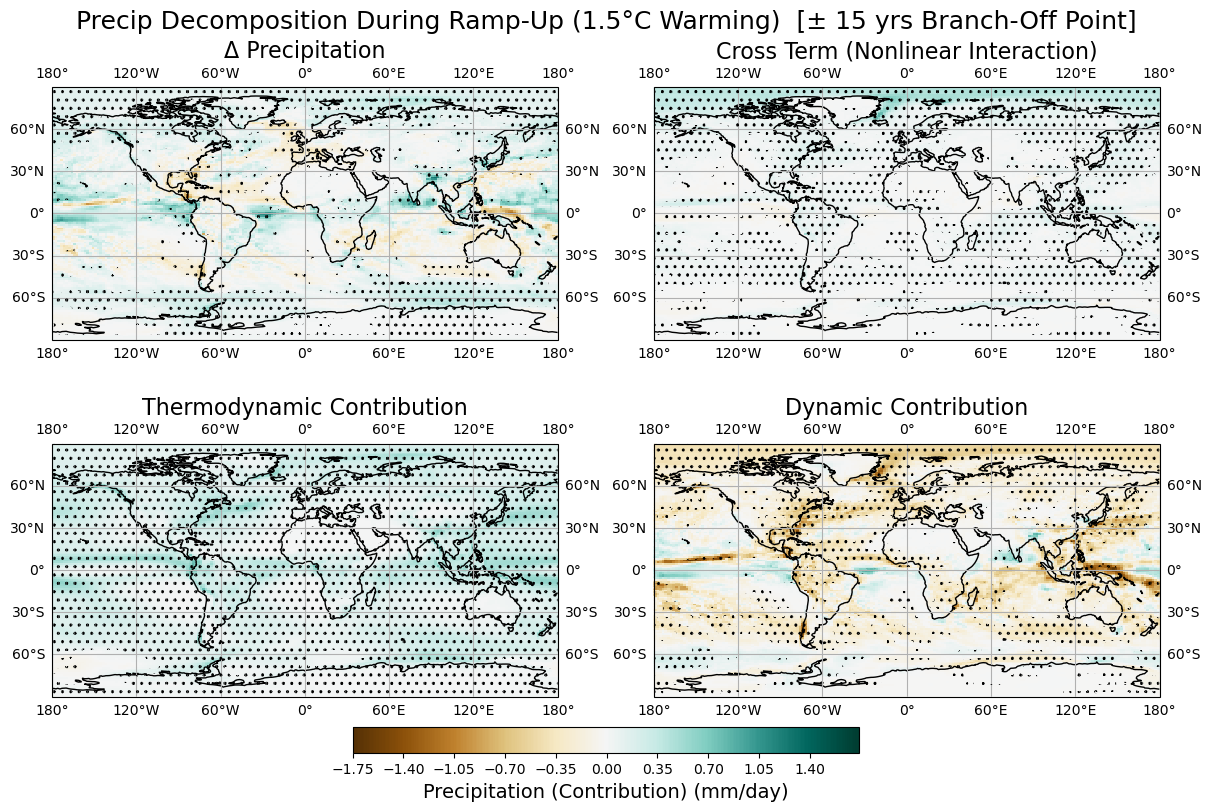

In [20]:
# This usually takes a while to load since it is handling very large datasets...
decomp_1p5_deg = anomaly_decomp_ds[new_names[0]]
scenario_1p5_deg = '1.5°C Warming'
filename_1p5_deg = f'{save_path}/decomposition_1.5-deg_ramp-up_window.png'
sup_title_1p5_deg = f'Precip Decomposition During Ramp-Up ({scenario_1p5_deg})  [± 15 yrs Branch-Off Point]'

decompose_results_map(decomp_1p5_deg, scenario_1p5_deg, lonmin, lonmax, latmin, latmax,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      save, filename_1p5_deg, sup_title_1p5_deg, p_vals_compiled_results_1p5deg)

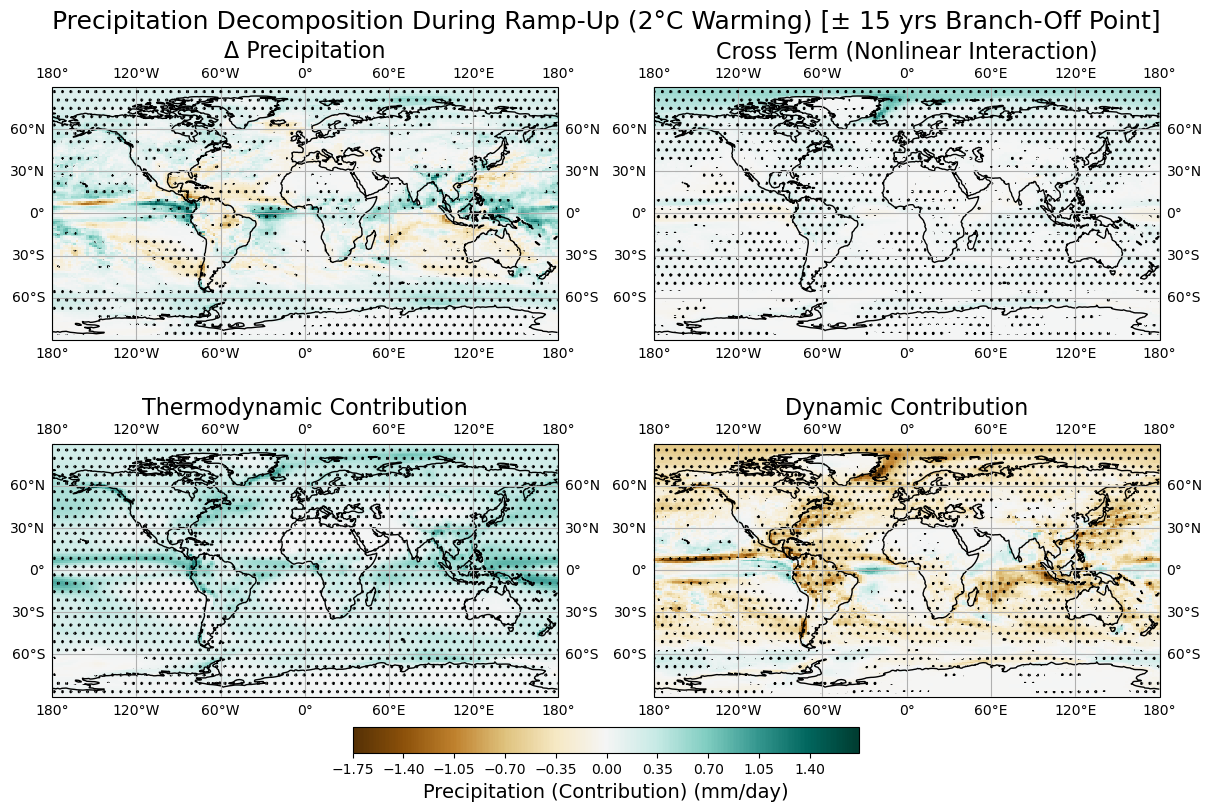

In [16]:
filename_2_deg = f'{save_path}/decomposition_2-deg_ramp-up_window.png'
decomp_2_deg = anomaly_decomp_ds[new_names[1]]
scenario_2_deg = '2°C Warming'
sup_title_2_deg = f'Precipitation Decomposition During Ramp-Up ({scenario_2_deg}) [± 15 yrs Branch-Off Point]'

decompose_results_map(decomp_2_deg, scenario_2_deg, lonmin, lonmax, latmin, latmax,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      save, filename_2_deg, sup_title_2_deg, p_vals_compiled_results_2deg)

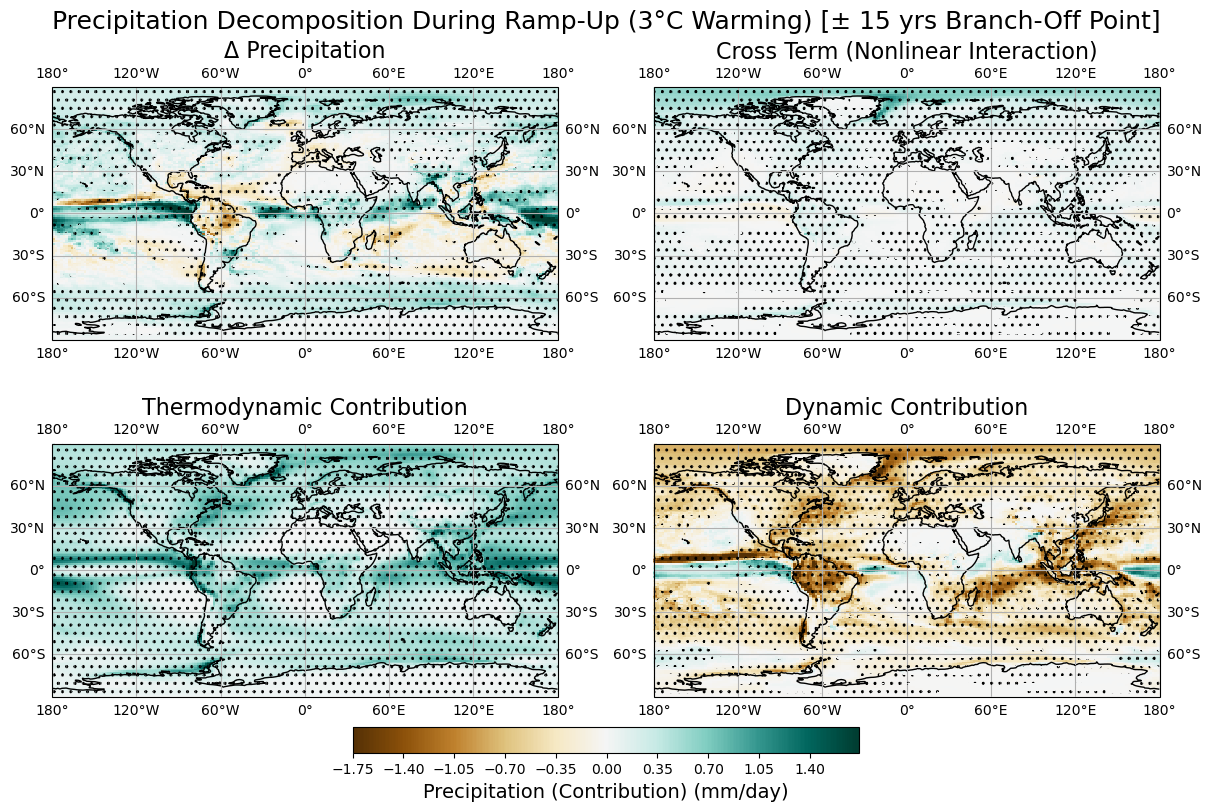

In [17]:
filename_3_deg = f'{save_path}/decomposition_3-deg_ramp-up_window.png'
decomp_3_deg = anomaly_decomp_ds[new_names[2]]
scenario_3_deg = '3°C Warming'
sup_title_3_deg = f'Precipitation Decomposition During Ramp-Up ({scenario_3_deg}) [± 15 yrs Branch-Off Point]'

decompose_results_map(decomp_3_deg, scenario_3_deg, lonmin, lonmax, latmin, latmax,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      save, filename_3_deg, sup_title_3_deg, p_vals_compiled_results_3deg)

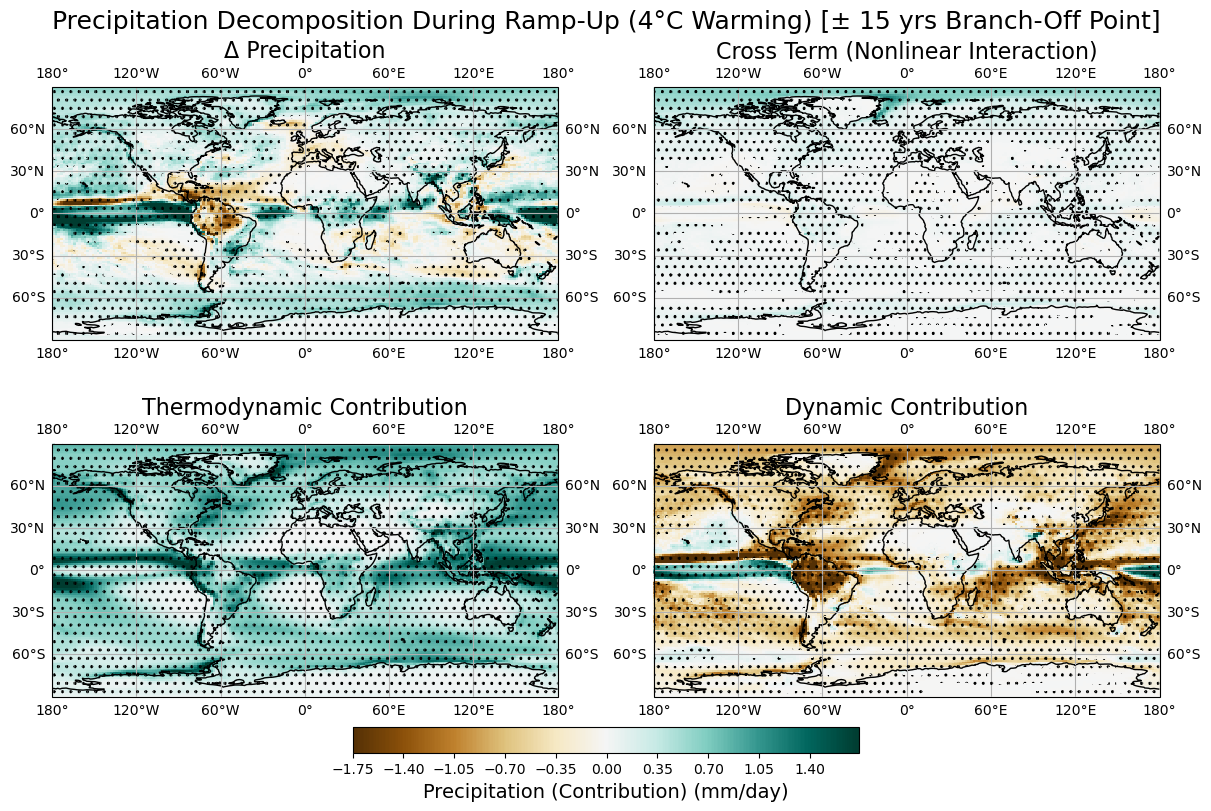

In [18]:
filename_4_deg = f'{save_path}/decomposition_4-deg_ramp-up_window.png'
decomp_4_deg = anomaly_decomp_ds[new_names[3]]
scenario_4_deg = '4°C Warming'
sup_title_4_deg = f'Precipitation Decomposition During Ramp-Up ({scenario_4_deg}) [± 15 yrs Branch-Off Point]'

decompose_results_map(decomp_4_deg, scenario_4_deg, lonmin, lonmax, latmin, latmax,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      save, filename_4_deg, sup_title_4_deg, p_vals_compiled_results_4deg)

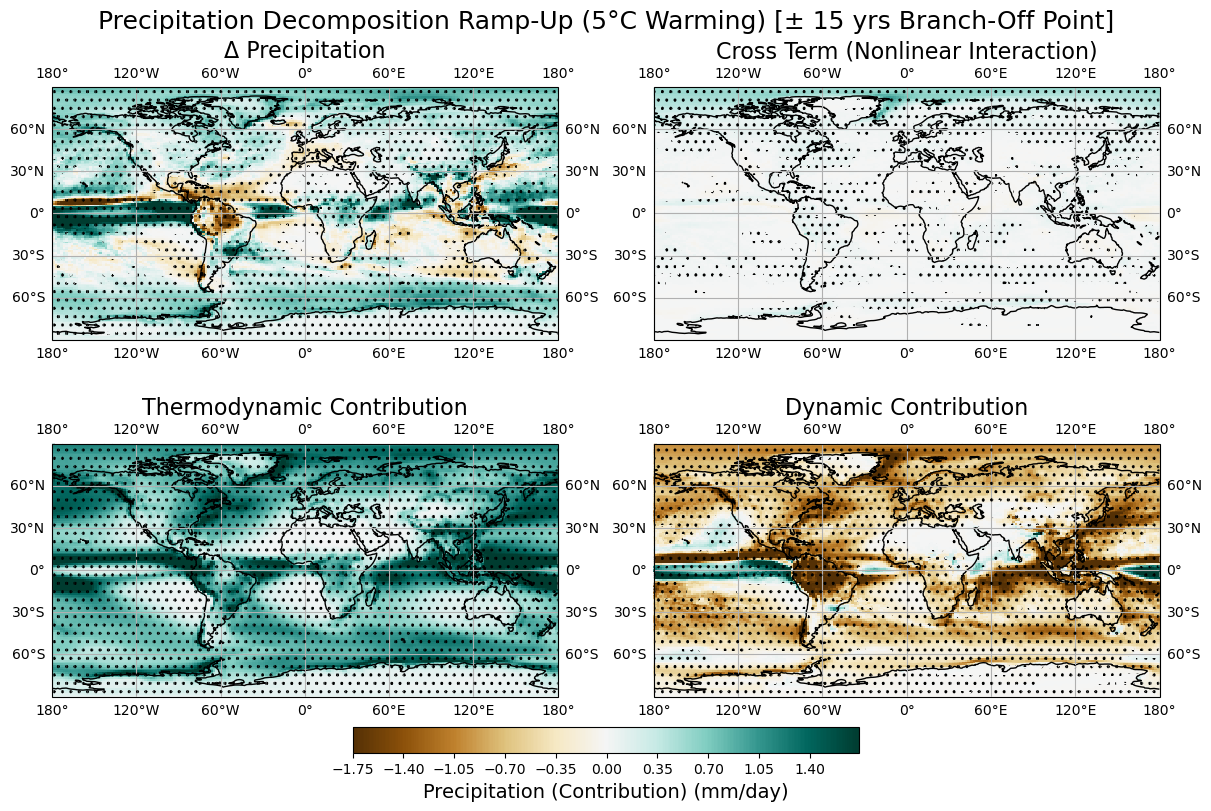

In [19]:
filename_5_deg = f'{save_path}/decomposition_5-deg_ramp-up_window.png'
decomp_5_deg = anomaly_decomp_ds[new_names[4]]
scenario_5_deg = '5°C Warming'
sup_title_5_deg = f'Precipitation Decomposition Ramp-Up ({scenario_5_deg}) [± 15 yrs Branch-Off Point]'

decompose_results_map(decomp_5_deg, scenario_5_deg, lonmin, lonmax, latmin, latmax,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      save, filename_5_deg, sup_title_5_deg, p_vals_compiled_results_5deg)

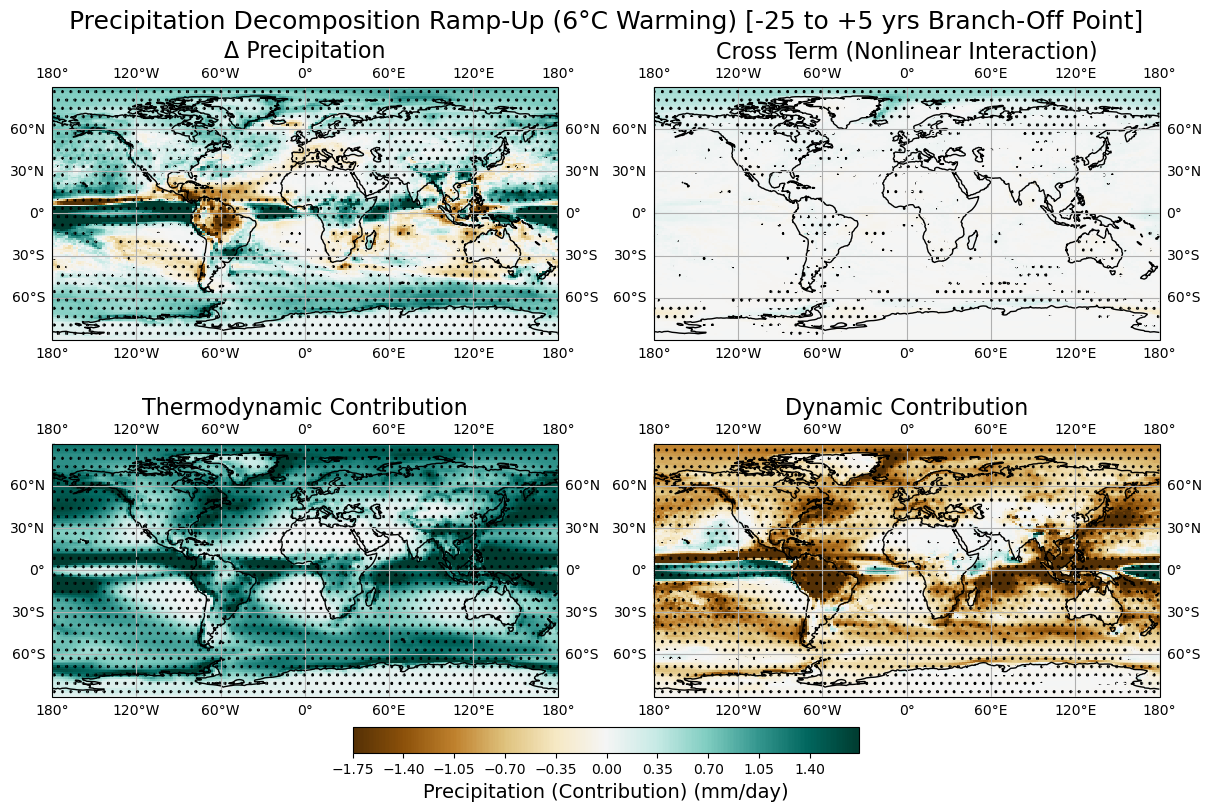

In [20]:
filename_6_deg = f'{save_path}/decomposition_6-deg_ramp-up_window.png'
decomp_6_deg = anomaly_decomp_ds[new_names[5]]
scenario_6_deg = '6°C Warming'
sup_title_6_deg = f'Precipitation Decomposition Ramp-Up ({scenario_6_deg}) [-25 to +5 yrs Branch-Off Point]'

decompose_results_map(decomp_6_deg, scenario_6_deg, lonmin, lonmax, latmin, latmax,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      save, filename_6_deg, sup_title_6_deg, p_vals_compiled_results_6deg)

### Resultant Figure B (Atlantic, Western Europe-Africa)

In [21]:
vmin_decomp, vmax_decomp = -1.75, 1.75
levels_decomp = np.arange(vmin_decomp, vmax_decomp, 0.01)

lonmin, lonmax = -60, 40
latmin, latmax = -20, 60

save = True
save_path = '/home/users/alvin_ch/figures/Multi-model/UKESM_ramp_up/Decomposition'

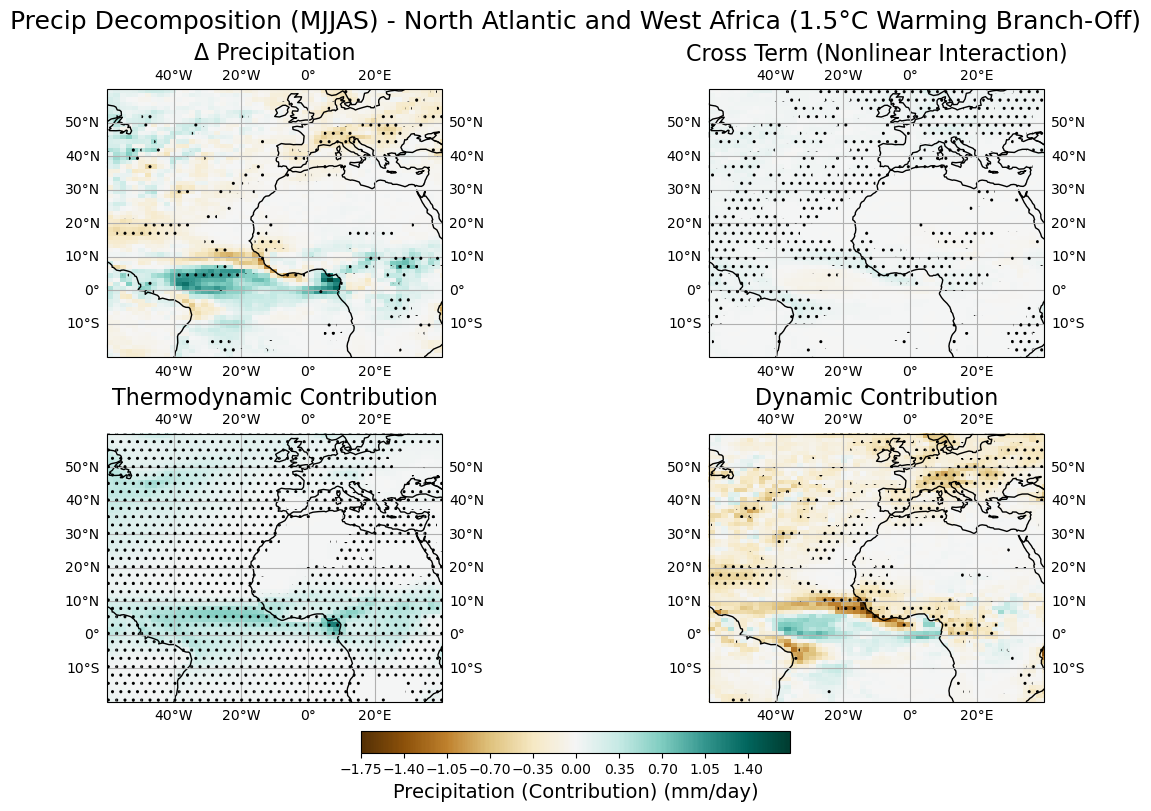

In [22]:
decomp_1p5_deg_atl = anomaly_MJJAS_decomp_ds[new_names[0]]
scenario_1p5_deg = '1.5°C Warming'
filename_1p5_deg_atl = f'{save_path}/decomposition_MJJAS_zoomed_1p5-deg_ramp-up_window.png'
sup_title_1p5_atl = f'Precip Decomposition (MJJAS) - North Atlantic and West Africa ({scenario_1p5_deg} Branch-Off)'

decompose_results_map(decomp_1p5_deg_atl, scenario_1p5_deg, lonmin, lonmax, latmin, latmax,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      save, filename_1p5_deg_atl, sup_title_1p5_atl, p_vals_compiled_results_1p5deg_MJJAS)

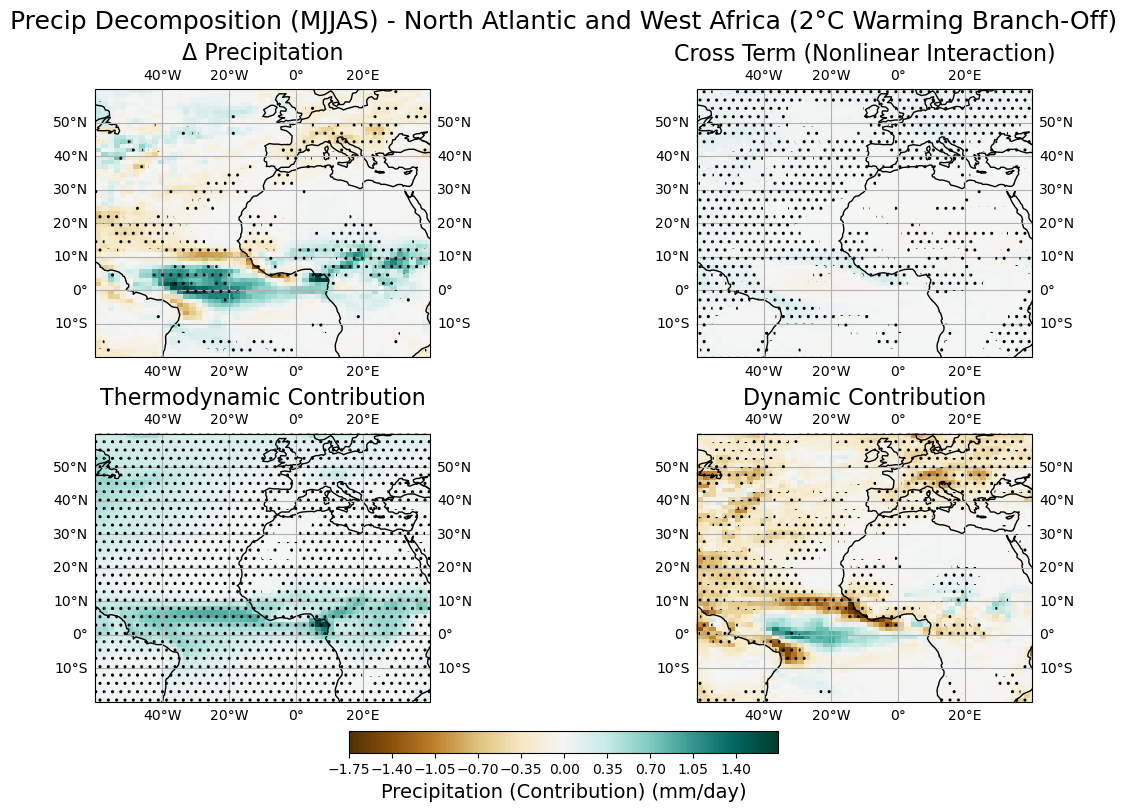

In [23]:
decomp_2_deg_atl = anomaly_MJJAS_decomp_ds[new_names[1]]
scenario_2_deg = '2°C Warming'
filename_2_deg_atl = f'{save_path}/decomposition_MJJAS_zoomed_2-deg_ramp-up_window.png'
sup_title_2_atl = f'Precip Decomposition (MJJAS) - North Atlantic and West Africa ({scenario_2_deg} Branch-Off)'

decompose_results_map(decomp_2_deg_atl, scenario_2_deg, lonmin, lonmax, latmin, latmax,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      save, filename_2_deg_atl, sup_title_2_atl, p_vals_compiled_results_2deg_MJJAS)

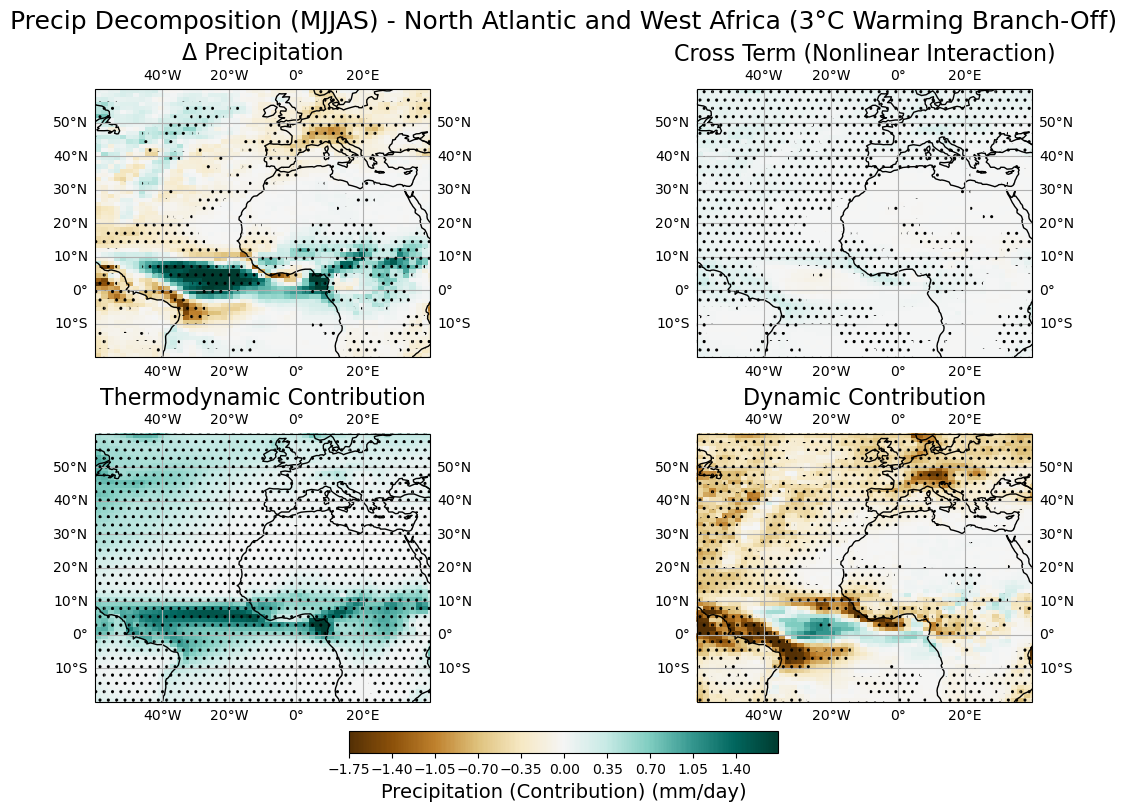

In [24]:
decomp_3_deg_atl = anomaly_MJJAS_decomp_ds[new_names[2]]
scenario_3_deg = '3°C Warming'
filename_3_deg_atl = f'{save_path}/decomposition_MJJAS_zoomed_3-deg_ramp-up_window.png'
sup_title_3_atl = f'Precip Decomposition (MJJAS) - North Atlantic and West Africa ({scenario_3_deg} Branch-Off)'

decompose_results_map(decomp_3_deg_atl, scenario_3_deg, lonmin, lonmax, latmin, latmax,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      save, filename_3_deg_atl, sup_title_3_atl, p_vals_compiled_results_3deg_MJJAS)

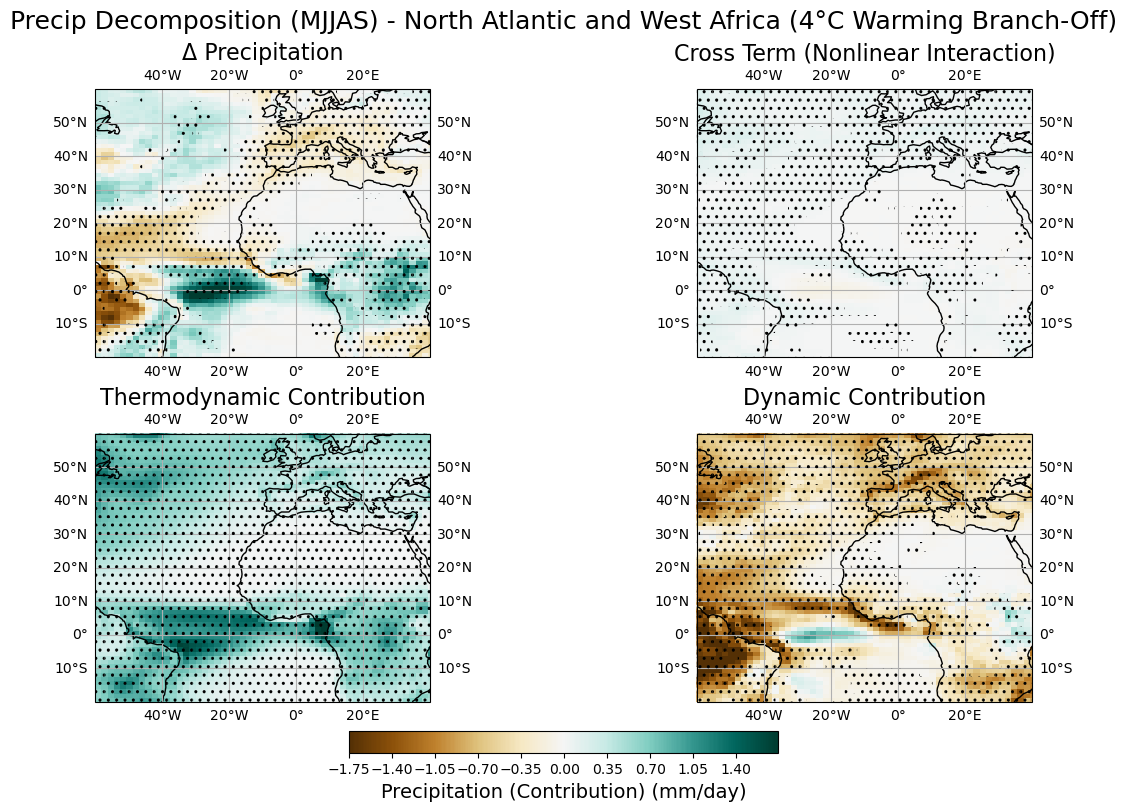

In [26]:
decomp_4_deg_atl = anomaly_decomp_ds[new_names[3]]
scenario_4_deg = '4°C Warming'
filename_4_deg_atl = f'{save_path}/decomposition_MJJAS_zoomed_4-deg_ramp-up_window.png'
sup_title_4_atl = f'Precip Decomposition (MJJAS) - North Atlantic and West Africa ({scenario_4_deg} Branch-Off)'

decompose_results_map(decomp_4_deg_atl, scenario_4_deg, lonmin, lonmax, latmin, latmax,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      save, filename_4_deg_atl, sup_title_4_atl, p_vals_compiled_results_4deg_MJJAS)

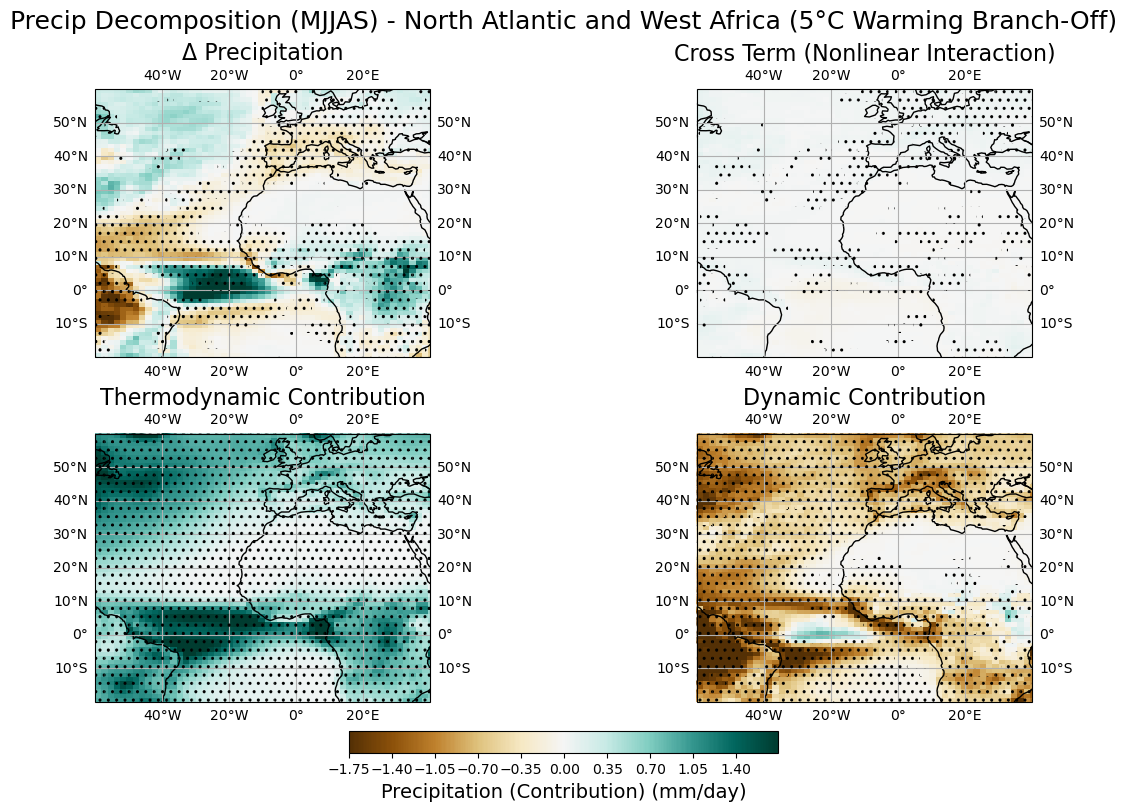

In [27]:
decomp_5_deg_atl = anomaly_decomp_ds[new_names[4]]
scenario_5_deg = '5°C Warming'
filename_5_deg_atl = f'{save_path}/decomposition_MJJAS_zoomed_5-deg_ramp-up_window.png'
sup_title_5_atl = f'Precip Decomposition (MJJAS) - North Atlantic and West Africa ({scenario_5_deg} Branch-Off)'

decompose_results_map(decomp_5_deg_atl, scenario_5_deg, lonmin, lonmax, latmin, latmax,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      save, filename_5_deg_atl, sup_title_5_atl, p_vals_compiled_results_5deg_MJJAS)

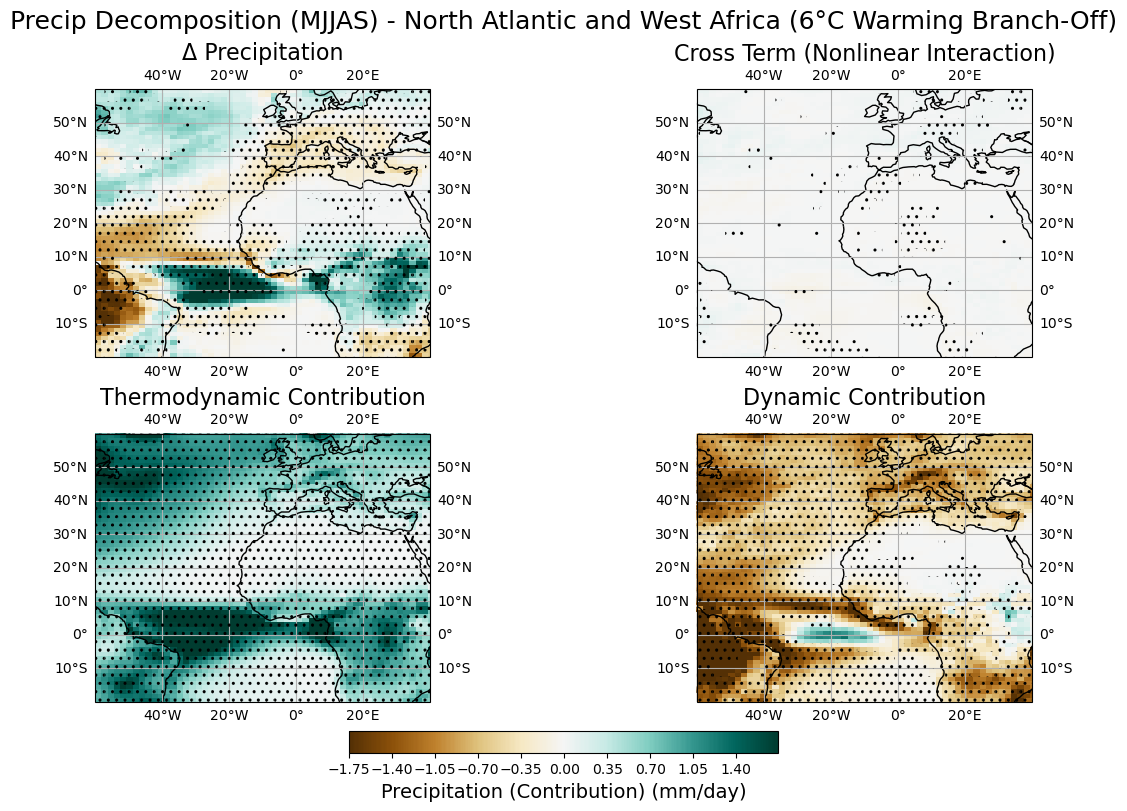

In [28]:
decomp_6_deg_atl = anomaly_decomp_ds[new_names[5]]
scenario_6_deg = '6°C Warming'
filename_6_deg_atl = f'{save_path}/decomposition_MJJAS_zoomed_6-deg_ramp-up_window.png'
sup_title_6_atl = f'Precip Decomposition (MJJAS) - North Atlantic and West Africa ({scenario_6_deg} Branch-Off)'

decompose_results_map(decomp_6_deg_atl, scenario_6_deg, lonmin, lonmax, latmin, latmax,
                      vmin_decomp, vmax_decomp, levels_decomp,
                      save, filename_6_deg_atl, sup_title_6_atl, p_vals_compiled_results_6deg_MJJAS)

### Animation

In [30]:
import imageio

overview_image_paths = [f'{save_path}/decomposition_1.5-deg_ramp-up_window.png',
                        f'{save_path}/decomposition_2-deg_ramp-up_window.png',
                        f'{save_path}/decomposition_3-deg_ramp-up_window.png',
                        f'{save_path}/decomposition_4-deg_ramp-up_window.png',
                        f'{save_path}/decomposition_5-deg_ramp-up_window.png', 
                        f'{save_path}/decomposition_6-deg_ramp-up_window.png']

frames = []

for path in overview_image_paths:
    # Read the image.
    img = imageio.imread(path)
    frames.append(img)

# Save as GIF
output_path = f'{save_path}/decomposition_overview_branch-off_compare.gif'
imageio.mimsave(output_path, frames, duration=1500, loop=0, quality=10)

In [31]:
zoomed_image_paths = [f'{save_path}/decomposition_MJJAS_zoomed_1p5-deg_ramp-up_window.png',
                      f'{save_path}/decomposition_MJJAS_zoomed_2-deg_ramp-up_window.png',
                      f'{save_path}/decomposition_MJJAS_zoomed_3-deg_ramp-up_window.png',
                      f'{save_path}/decomposition_MJJAS_zoomed_4-deg_ramp-up_window.png',
                      f'{save_path}/decomposition_MJJAS_zoomed_5-deg_ramp-up_window.png',
                      f'{save_path}/decomposition_MJJAS_zoomed_6-deg_ramp-up_window.png']

frames = []

for path in zoomed_image_paths:
    # Read the image.
    img = imageio.imread(path)
    frames.append(img)

# Find smallest height and width.
min_height = min(img.shape[0] for img in frames)
min_width = min(img.shape[1] for img in frames)

# Crop all frames to the same dimensions.
frames = [img[:min_height, :min_width] for img in frames]

# Save as GIF
output_path = f'{save_path}/decomposition_zoomed_branch-off_compare.gif'
imageio.mimsave(output_path, frames, duration=1500, loop=0, quality=10)